# Routing label and baseline router

This notebook turns the long table from the EDA into a supervised problem. The label
for each prompt is the cheapest model that still answered well, "well" meaning its
score cleared a quality threshold. I used threshold 1.0 as the primary rule (the model
actually solved the prompt; nine of ten datasets only grade 0 or 1 anyway) and 0.5 as
the sensitivity setting (it additionally accepts arenahard draws). If no model cleared
the bar I labeled the prompt with the cheapest model overall, because when every answer
is wrong the only thing left to optimize is losing less money.

Then I trained the first router: multinomial logistic regression on a light feature
set (prompt size and task category), evaluated against always-cheapest and
always-strongest baselines. The split is by prompt, and since the modeling table has
exactly one row per prompt, a plain row split cannot leak the same prompt into both
sides the way a split on the raw long table would.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

sys.path.insert(0, str(Path("..") / "src"))
from routing_label import assign_router_labels

df = pd.read_parquet(Path("..") / "data" / "processed" / "records_long.parquet")
core = df[~df.is_reference].copy()

# keep only prompts where the full 13-model menu is present, so every label
# comes from the same comparison; also drop the 2 prompts where the query text
# did not match across models (bad index alignment in the source files)
n_models = core.model.nunique()
coverage = core.groupby("prompt_id")["model"].nunique()
full_menu = coverage[coverage == n_models].index
hash_check = core.groupby("prompt_id")["query_hash"].nunique()
aligned = hash_check[hash_check == 1].index
keep = full_menu.intersection(aligned)
core = core[core.prompt_id.isin(keep)]
print(f"prompts kept: {core.prompt_id.nunique():,}")

prompts kept: 12,166


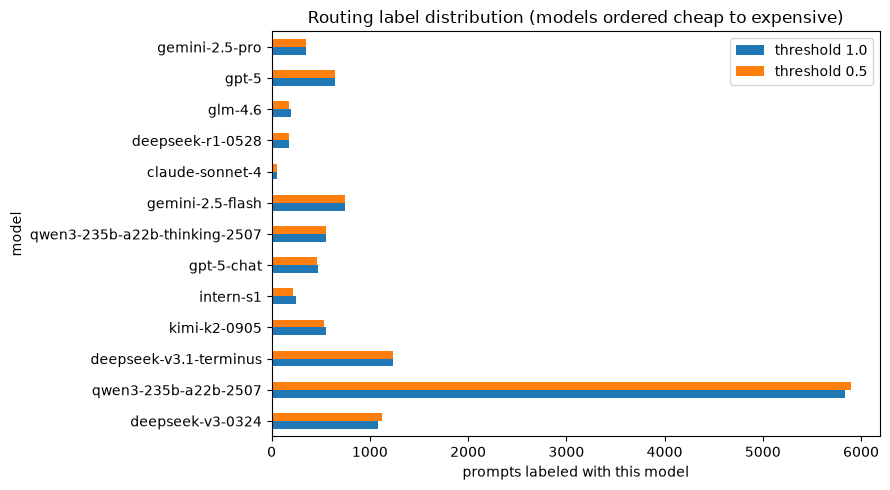

label changed between thresholds on 2.1% of prompts
prompts where nobody cleared threshold 1.0: 18.0%


In [2]:
labels_100 = assign_router_labels(core, threshold=1.0)
labels_050 = assign_router_labels(core, threshold=0.5)

order = core.groupby("model")["cost"].mean().sort_values().index
dist = pd.DataFrame({
    "threshold 1.0": labels_100.label.value_counts(),
    "threshold 0.5": labels_050.label.value_counts(),
}).reindex(order).fillna(0).astype(int)

fig, ax = plt.subplots(figsize=(9, 5))
dist.plot.barh(ax=ax)
ax.set_xlabel("prompts labeled with this model")
ax.set_title("Routing label distribution (models ordered cheap to expensive)")
plt.tight_layout()
plt.show()
print("label changed between thresholds on",
      f"{(labels_100.label != labels_050.label).mean():.1%} of prompts")
print("prompts where nobody cleared threshold 1.0:",
      f"{(labels_100.n_capable == 0).mean():.1%}")

One casualty of the full-menu filter worth naming: every tau2 prompt dropped out,
because gpt-5-chat was never run on tau2 in the benchmark release. So the modeling
set is really 9 of the 10 Performance-Cost datasets plus the two misaligned prompts,
12,166 prompts total.

The distribution leans hard toward the cheap end, which is the point: whenever the
cheapest model gets the answer right it IS the correct routing target, and it is right
often enough to dominate. The two expensive frontier models still collect a real share
of labels, those are the prompts only they can solve. Moving the threshold from 1.0 to
0.5 only relabels a small slice of prompts (arenahard draws), so the label rule is not
hanging on a knife-edge threshold choice.

In [3]:
# one modeling row per prompt: model-independent features only.
# prompt_tokens differs per model (different tokenizers), so I took the median
# across the 13 models as a single prompt-size measure known before routing.
feats = core.groupby("prompt_id").agg(
    dataset=("dataset", "first"),
    query_chars=("query_chars", "first"),
    med_prompt_tokens=("prompt_tokens", "median"),
).reset_index()
model_df = feats.merge(labels_100[["prompt_id", "label"]], on="prompt_id")
model_df.head()

,prompt_id,dataset,query_chars,med_prompt_tokens,label
0,aime:1,aime,380,210.0,gpt-5-chat
1,aime:10,aime,237,122.0,gpt-5-chat
2,aime:11,aime,117,107.0,gpt-5-chat
3,aime:12,aime,394,193.0,gpt-5-chat
4,aime:13,aime,519,194.0,gpt-5-chat


In [4]:
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

train_df, test_df = train_test_split(
    model_df, test_size=0.2, random_state=42, stratify=model_df.dataset)

feature_cols = ["dataset", "query_chars", "med_prompt_tokens"]
prep = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), ["dataset"]),
    ("num", StandardScaler(), ["query_chars", "med_prompt_tokens"]),
])
router = Pipeline([
    ("prep", prep),
    ("clf", LogisticRegression(max_iter=2000)),
])
router.fit(train_df[feature_cols], train_df.label)
pred = router.predict(test_df[feature_cols])
print(f"test accuracy: {accuracy_score(test_df.label, pred):.3f}")
print(f"test macro F1: {f1_score(test_df.label, pred, average='macro'):.3f}")

test accuracy: 0.490
test macro F1: 0.120


Raw accuracy against a 13-class label with heavy imbalance is a blunt measure, and the
macro F1 shows the classifier mostly learned the big classes. For a router the economic
scoreboard matters more: what did the routed traffic cost, and how often was the answer
good. So I scored every test prompt by actually looking up the cost and score of
whichever model the router picked.

In [5]:
# economic evaluation on the test prompts
menu = core[core.prompt_id.isin(test_df.prompt_id)]
lookup = menu.set_index(["prompt_id", "model"])[["cost", "score"]]

def route_outcome(picks):
    # picks: Series prompt_id -> model chosen; returns mean cost and mean score
    idx = list(zip(picks.index, picks.values, strict=True))
    got = lookup.loc[idx]
    return got.cost.mean(), got.score.mean()

cheapest_model = core.groupby("model").cost.mean().idxmin()
strongest_model = core.groupby("model").score.mean().idxmax()
test_ids = test_df.prompt_id

strategies = {
    "always cheapest": pd.Series(cheapest_model, index=test_ids),
    "always strongest": pd.Series(strongest_model, index=test_ids),
    "logistic router": pd.Series(pred, index=test_ids),
    "oracle label": pd.Series(test_df.label.values, index=test_ids),
}
rows = []
for name, picks in strategies.items():
    cost, score = route_outcome(picks)
    rows.append({"strategy": name, "mean cost (USD)": cost, "mean score": score})
scoreboard = pd.DataFrame(rows).set_index("strategy")
scoreboard.round(4)

,mean cost (USD),mean score
strategy,,
always cheapest,0.0008,0.4287
always strongest,0.0615,0.5968
logistic router,0.0115,0.5637
oracle label,0.0055,0.8215


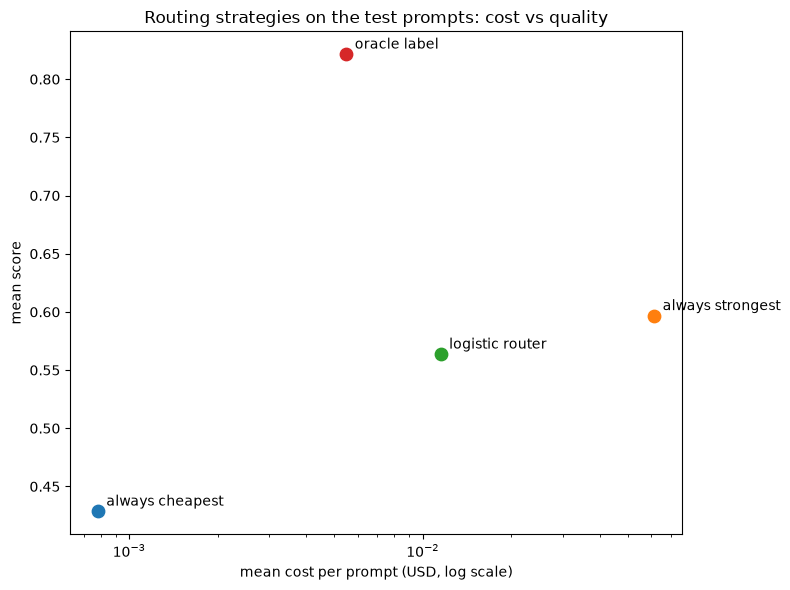

In [6]:
fig, ax = plt.subplots(figsize=(8, 6))
for name, row in scoreboard.iterrows():
    ax.scatter(row["mean cost (USD)"], row["mean score"], s=80)
    ax.annotate(name, (row["mean cost (USD)"], row["mean score"]),
                xytext=(6, 4), textcoords="offset points")
ax.set_xscale("log")
ax.set_xlabel("mean cost per prompt (USD, log scale)")
ax.set_ylabel("mean score")
ax.set_title("Routing strategies on the test prompts: cost vs quality")
plt.tight_layout()
plt.show()

Reading the scoreboard: the oracle shows the ceiling, a 0.82 mean score for about a
tenth of what always-strongest spends, and the gap between the logistic router and
that ceiling is the room the tuned models in the next notebook have to close. The router already beats
always-cheapest on quality and always-strongest on cost, which is the minimum bar for
a routing idea to be worth anything.

In [7]:
# sensitivity: same router trained on the threshold-0.5 labels
model_df_050 = feats.merge(labels_050[["prompt_id", "label"]], on="prompt_id")
tr50 = model_df_050[model_df_050.prompt_id.isin(train_df.prompt_id)]
te50 = model_df_050[model_df_050.prompt_id.isin(test_df.prompt_id)]
router50 = Pipeline([
    ("prep", prep),
    ("clf", LogisticRegression(max_iter=2000)),
])
router50.fit(tr50[feature_cols], tr50.label)
pred50 = router50.predict(te50[feature_cols])
cost50, score50 = route_outcome(pd.Series(pred50, index=te50.prompt_id))
print(f"threshold 0.5 router -> mean cost {cost50:.4f}, mean score {score50:.4f}")
print(f"threshold 1.0 router -> mean cost "
      f"{scoreboard.loc['logistic router', 'mean cost (USD)']:.4f}, mean score "
      f"{scoreboard.loc['logistic router', 'mean score']:.4f}")

threshold 0.5 router -> mean cost 0.0115, mean score 0.5637
threshold 1.0 router -> mean cost 0.0115, mean score 0.5637


The routed cost and quality barely move between the two threshold settings, which backs
up the earlier read: with mostly binary scoring, the threshold choice is not doing
hidden work in the results. Threshold 1.0 stays the primary rule for the tuned models.

In [8]:
# save the per-prompt modeling tables for the tuning notebooks
out = Path("..") / "data" / "processed"
model_df.to_parquet(out / "prompts_features_labels_tau100.parquet", index=False)
model_df_050.to_parquet(out / "prompts_features_labels_tau050.parquet", index=False)
print("saved modeling tables:", len(model_df), "prompts")

saved modeling tables: 12166 prompts
